In [1]:
#Import Libraries & Load Dataset

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots display in Jupyter
%matplotlib inline

# Load dataset
data = pd.read_csv("Dataset .csv")

# Preview relevant columns
data[['Restaurant Name', 'Price range', 'Has Online delivery', 'Has Table booking']].head()


,Restaurant Name,Price range,Has Online delivery,Has Table booking
0,Le Petit Souffle,3,No,Yes
1,Izakaya Kikufuji,3,No,Yes
2,Heat - Edsa Shangri-La,4,No,Yes
3,Ooma,4,No,No
4,Sambo Kojin,4,No,Yes


In [11]:
#Convert Yes/No to Numeric

In [13]:
# Replace Yes/No or Y/N with 1/0
data['Has Online delivery'] = data['Has Online delivery'].replace({'Yes':1, 'No':0, 'Y':1, 'N':0}).astype(int)
data['Has Table booking'] = data['Has Table booking'].replace({'Yes':1, 'No':0, 'Y':1, 'N':0}).astype(int)

# Ensure Price range is numeric
data['Price range'] = pd.to_numeric(data['Price range'], errors='coerce')

# Drop rows with missing Price range
data_clean = data.dropna(subset=['Price range'])


In [5]:
#Online Delivery by Price Range

C:\Users\DELL\AppData\Local\Temp\ipykernel_41852\1746059309.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=online_delivery_stats.index, y=online_delivery_stats.values, palette='Blues_d')


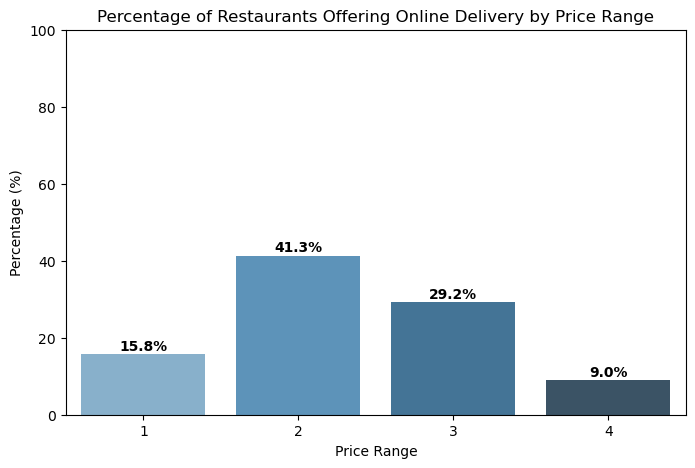

In [14]:
# Percentage of restaurants with online delivery per price range
online_delivery_stats = data_clean.groupby('Price range')['Has Online delivery'].mean() * 100

# Plot with labels on top of bars
plt.figure(figsize=(8,5))
sns.barplot(x=online_delivery_stats.index, y=online_delivery_stats.values, palette='Blues_d')

# Add value labels on top of bars
for i, v in enumerate(online_delivery_stats.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

plt.title("Percentage of Restaurants Offering Online Delivery by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.show()


In [7]:
#Table Booking by Price Range

C:\Users\DELL\AppData\Local\Temp\ipykernel_41852\2335962284.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=table_booking_stats.index, y=table_booking_stats.values, palette='Greens_d')


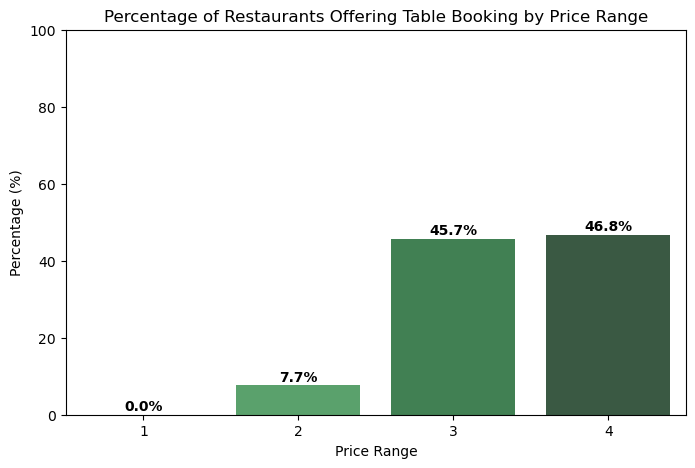

In [15]:
# Percentage of restaurants with table booking per price range
table_booking_stats = data_clean.groupby('Price range')['Has Table booking'].mean() * 100

# Plot with labels on top of bars
plt.figure(figsize=(8,5))
sns.barplot(x=table_booking_stats.index, y=table_booking_stats.values, palette='Greens_d')

for i, v in enumerate(table_booking_stats.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

plt.title("Percentage of Restaurants Offering Table Booking by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.show()


In [16]:
#Observations

In [18]:
print("Observations:")
print(f"• Price range with highest online delivery: {online_delivery_stats.idxmax()} → {online_delivery_stats.max():.2f}%")
print(f"• Price range with highest table booking: {table_booking_stats.idxmax()} → {table_booking_stats.max():.2f}%")

print("\n• Interpretation:")
if online_delivery_stats.idxmax() == data_clean['Price range'].max():
    print("  - Higher-priced restaurants are more likely to offer online delivery.")
else:
    print("  - Online delivery is not strictly increasing with price.")

if table_booking_stats.idxmax() == data_clean['Price range'].max():
    print("  - Higher-priced restaurants are more likely to offer table booking.")
else:
    print("  - Table booking is not strictly increasing with price.")


Observations:
• Price range with highest online delivery: 2 → 41.31%
• Price range with highest table booking: 4 → 46.76%

• Interpretation:
  - Online delivery is not strictly increasing with price.
  - Higher-priced restaurants are more likely to offer table booking.
